<a href="https://colab.research.google.com/github/NischalGrg5555/AI-Level-6/blob/main/Worksheet_8_Nischal_Gurung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nischal Gurung - Workshop 8

**1. Data Preprocessing & Cleaning**

In [6]:
pip install emoji

In [7]:
import re
import nltk
import string
import emoji
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
def text_cleaning_pipeline(text, rule="lemmatize"):
    """
    Cleans text data using several preprocessing steps.

    Args:
        text (str): Raw input text.
        rule (str): 'lemmatize' or 'stem'.

    Returns:
        str: Cleaned and processed text.
    """

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)

    # Remove emojis
    text = emoji.replace_emoji(text, replace='')

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Tokenize
    tokens = text.split()

    # Remove stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization or stemming
    if rule == "lemmatize":
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    elif rule == "stem":
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(word) for word in tokens]
    else:
        raise ValueError("Invalid rule. Choose between 'lemmatize' or 'stem'.")

    return " ".join(tokens)

In [9]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/AI/Week 8/trum_tweet_sentiment_analysis.csv')

In [11]:
data.columns

Index(['text', 'Sentiment'], dtype='object')

In [12]:
from tqdm.notebook import tqdm
tqdm.pandas()

data['cleaned_text'] = data['text'].progress_apply(lambda x: text_cleaning_pipeline(x, rule="lemmatize"))


  0%|          | 0/1850123 [00:00<?, ?it/s]

**2. Tokenization & Padding**

In [13]:
data.rename(columns={'Sentiment': 'sentiment'}, inplace=True)

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data['sentiment_encoded'] = label_encoder.fit_transform(data['sentiment'])

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data['cleaned_text'],
    data['sentiment_encoded'],
    test_size=0.2,
    random_state=42
)

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [17]:
import numpy as np

seq_lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(seq_lengths, 95))


In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# Convert labels to NumPy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)


**3. Model Building**

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

vocab_size = 10000
embedding_dim = 128


In [20]:
#  RNN Model
rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [21]:
rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [22]:
# LSTM Model
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

In [23]:
lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

**4. Training & Evaluation**

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


In [25]:
# Train RNN
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
37003/37003 ━━━━━━━━━━━━━━━━━━━━ 192s 5ms/step - accuracy: 0.9352 - loss: 0.1727 - val_accuracy: 0.9513 - val_loss: 0.1394
Epoch 2/5
37003/37003 ━━━━━━━━━━━━━━━━━━━━ 183s 5ms/step - accuracy: 0.9566 - loss: 0.1253 - val_accuracy: 0.9551 - val_loss: 0.1322
Epoch 3/5
37003/37003 ━━━━━━━━━━━━━━━━━━━━ 189s 5ms/step - accuracy: 0.9593 - loss: 0.1184 - val_accuracy: 0.9542 - val_loss: 0.1326
Epoch 4/5
37003/37003 ━━━━━━━━━━━━━━━━━━━━ 184s 5ms/step - accuracy: 0.9590 - loss: 0.1197 - val_accuracy: 0.9505 - val_loss: 0.1468


In [26]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 17, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,877,253 (14.79 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,584,836 (9.86 MB)

11564/11564 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step


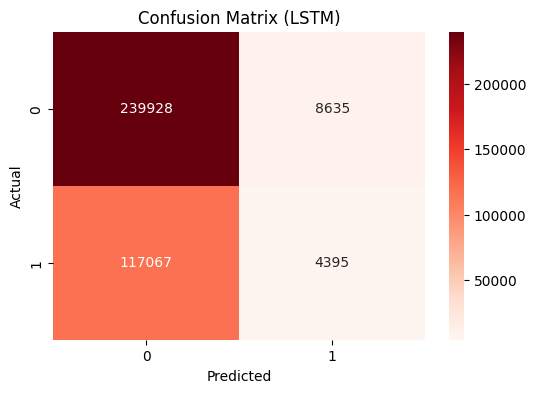

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict on test data using LSTM model
y_pred_probs = lstm_model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (LSTM)')
plt.show()

In [29]:
# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:

              precision    recall  f1-score   support

           0     0.6721    0.9653    0.7924    248563
           1     0.3373    0.0362    0.0654    121462

    accuracy                         0.6603    370025
   macro avg     0.5047    0.5007    0.4289    370025
weighted avg     0.5622    0.6603    0.5538    370025

